In [ ]:
import os
import sys
sys.path.append('/home/reabt/experiments/ncc/MRI/code/')

from utils.load_cfg import load_config_instance
from utils.files import fix_spm_rawdata_paths
from utils.plots import plot_overlay_on_mask
from utils.rsa import get_searchlight_RDMs_crossnobis

import joblib
import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.colors
import seaborn as sns

from nilearn import plotting
from nilearn.image import new_img_like

import rsatoolbox as rsa
from rsatoolbox.io.spm import SpmGlm
from rsatoolbox.data import Dataset
from rsatoolbox.data.noise import prec_from_residuals
from rsatoolbox.inference import eval_fixed
from rsatoolbox.util.searchlight import (
    get_volume_searchlight,
    get_searchlight_RDMs,
    evaluate_models_searchlight
)

from plus_slurm import Job
from configs.config2 import BaseConfig as cfg
import importlib
import configs.config as config
importlib.reload(config)
from configs.config2 import BaseConfig as cfg

from io import BytesIO
from PIL import Image


In [ ]:
subjectID = '19910823ssld'
maskNr = 0
config_class_name = 'SetupConfig_E1' # trying Euclidean distance again

print('----------------------------------------------------')
print('running...')
print(f'     - subject:       {subjectID}')
print(f'     - maskNr:        {maskNr}')
print(f'     - configuration: {config_class_name}')
print('----------------------------------------------------')

# 1) load instance of selected class object --> this loads all the settings for the computations

cfg = load_config_instance(config_class_name, subjectID, maskNr) 
cfg.print_summary()
cfg.save_summary()
paths = cfg.get_paths()
outFiles = cfg.get_outFile_names()

dataDir = paths['dataDir']
spmDir = paths['spmDir']
outDir = paths['outDir']
maskFile = paths['maskFile']       
model = cfg.get_model_RDM()


# print(f'Running crossnobis Searchlight part {maskNr}', flush=True)
os.makedirs(outDir, exist_ok=True)

# 2) defining and loading some more variables
spm = SpmGlm(spmDir)
spm.get_info_from_spm_mat()

# print('    - Renaming rawdata file paths in SPM.mat...', flush=True)
fix_spm_rawdata_paths(spm, dataDir + 'sync')    


# print('    - Loading betas and info...', flush=True)
betas, _, info = spm.get_betas(maskFile)
info = pd.DataFrame(info)
reg_mask = info['reg_name'].str.contains('_hit') | info['reg_name'].str.contains('_miss')

nfo = info[reg_mask].reset_index(drop=True)
info['modality'] = info['reg_name'].str.extract(r'^(aud|tac|vis)')
info['awareness'] = info['reg_name'].str.extract(r'_(hit|miss)')
info['condition'] = info['modality'] + '_' + info['awareness']

betas = betas[reg_mask.to_numpy(), :]

# print('    - Loading full brain Mask...', flush=True)
mask = nib.load(maskFile)
mask_bool = mask.get_fdata() > 0
n_voxels_total = np.prod(mask_bool.shape)
mask_bool_1D = mask_bool.flatten()
mask_bool_1D_idx = np.where(mask_bool_1D)[0] # shape=(95797,)

----------------------------------------------------
running...
     - subject:       19910823ssld
     - maskNr:        0
     - configuration: SetupConfig_E1
----------------------------------------------------

------Configuration Summary ------

We are using the First Level Model: > M4B < from directory firstLevel_supraSens_M4B
6 conditions were defined
Model RDM Type:     suprasensory
RDM Method:         euclidean
RSA Method:         spearman
Searchlights have a radious of > 2 < voxels, with a threshold of > 0.5 <
Mask used: > full brain mask <

----------------------------------



## Plot the Betas (each Beta in one subplot)

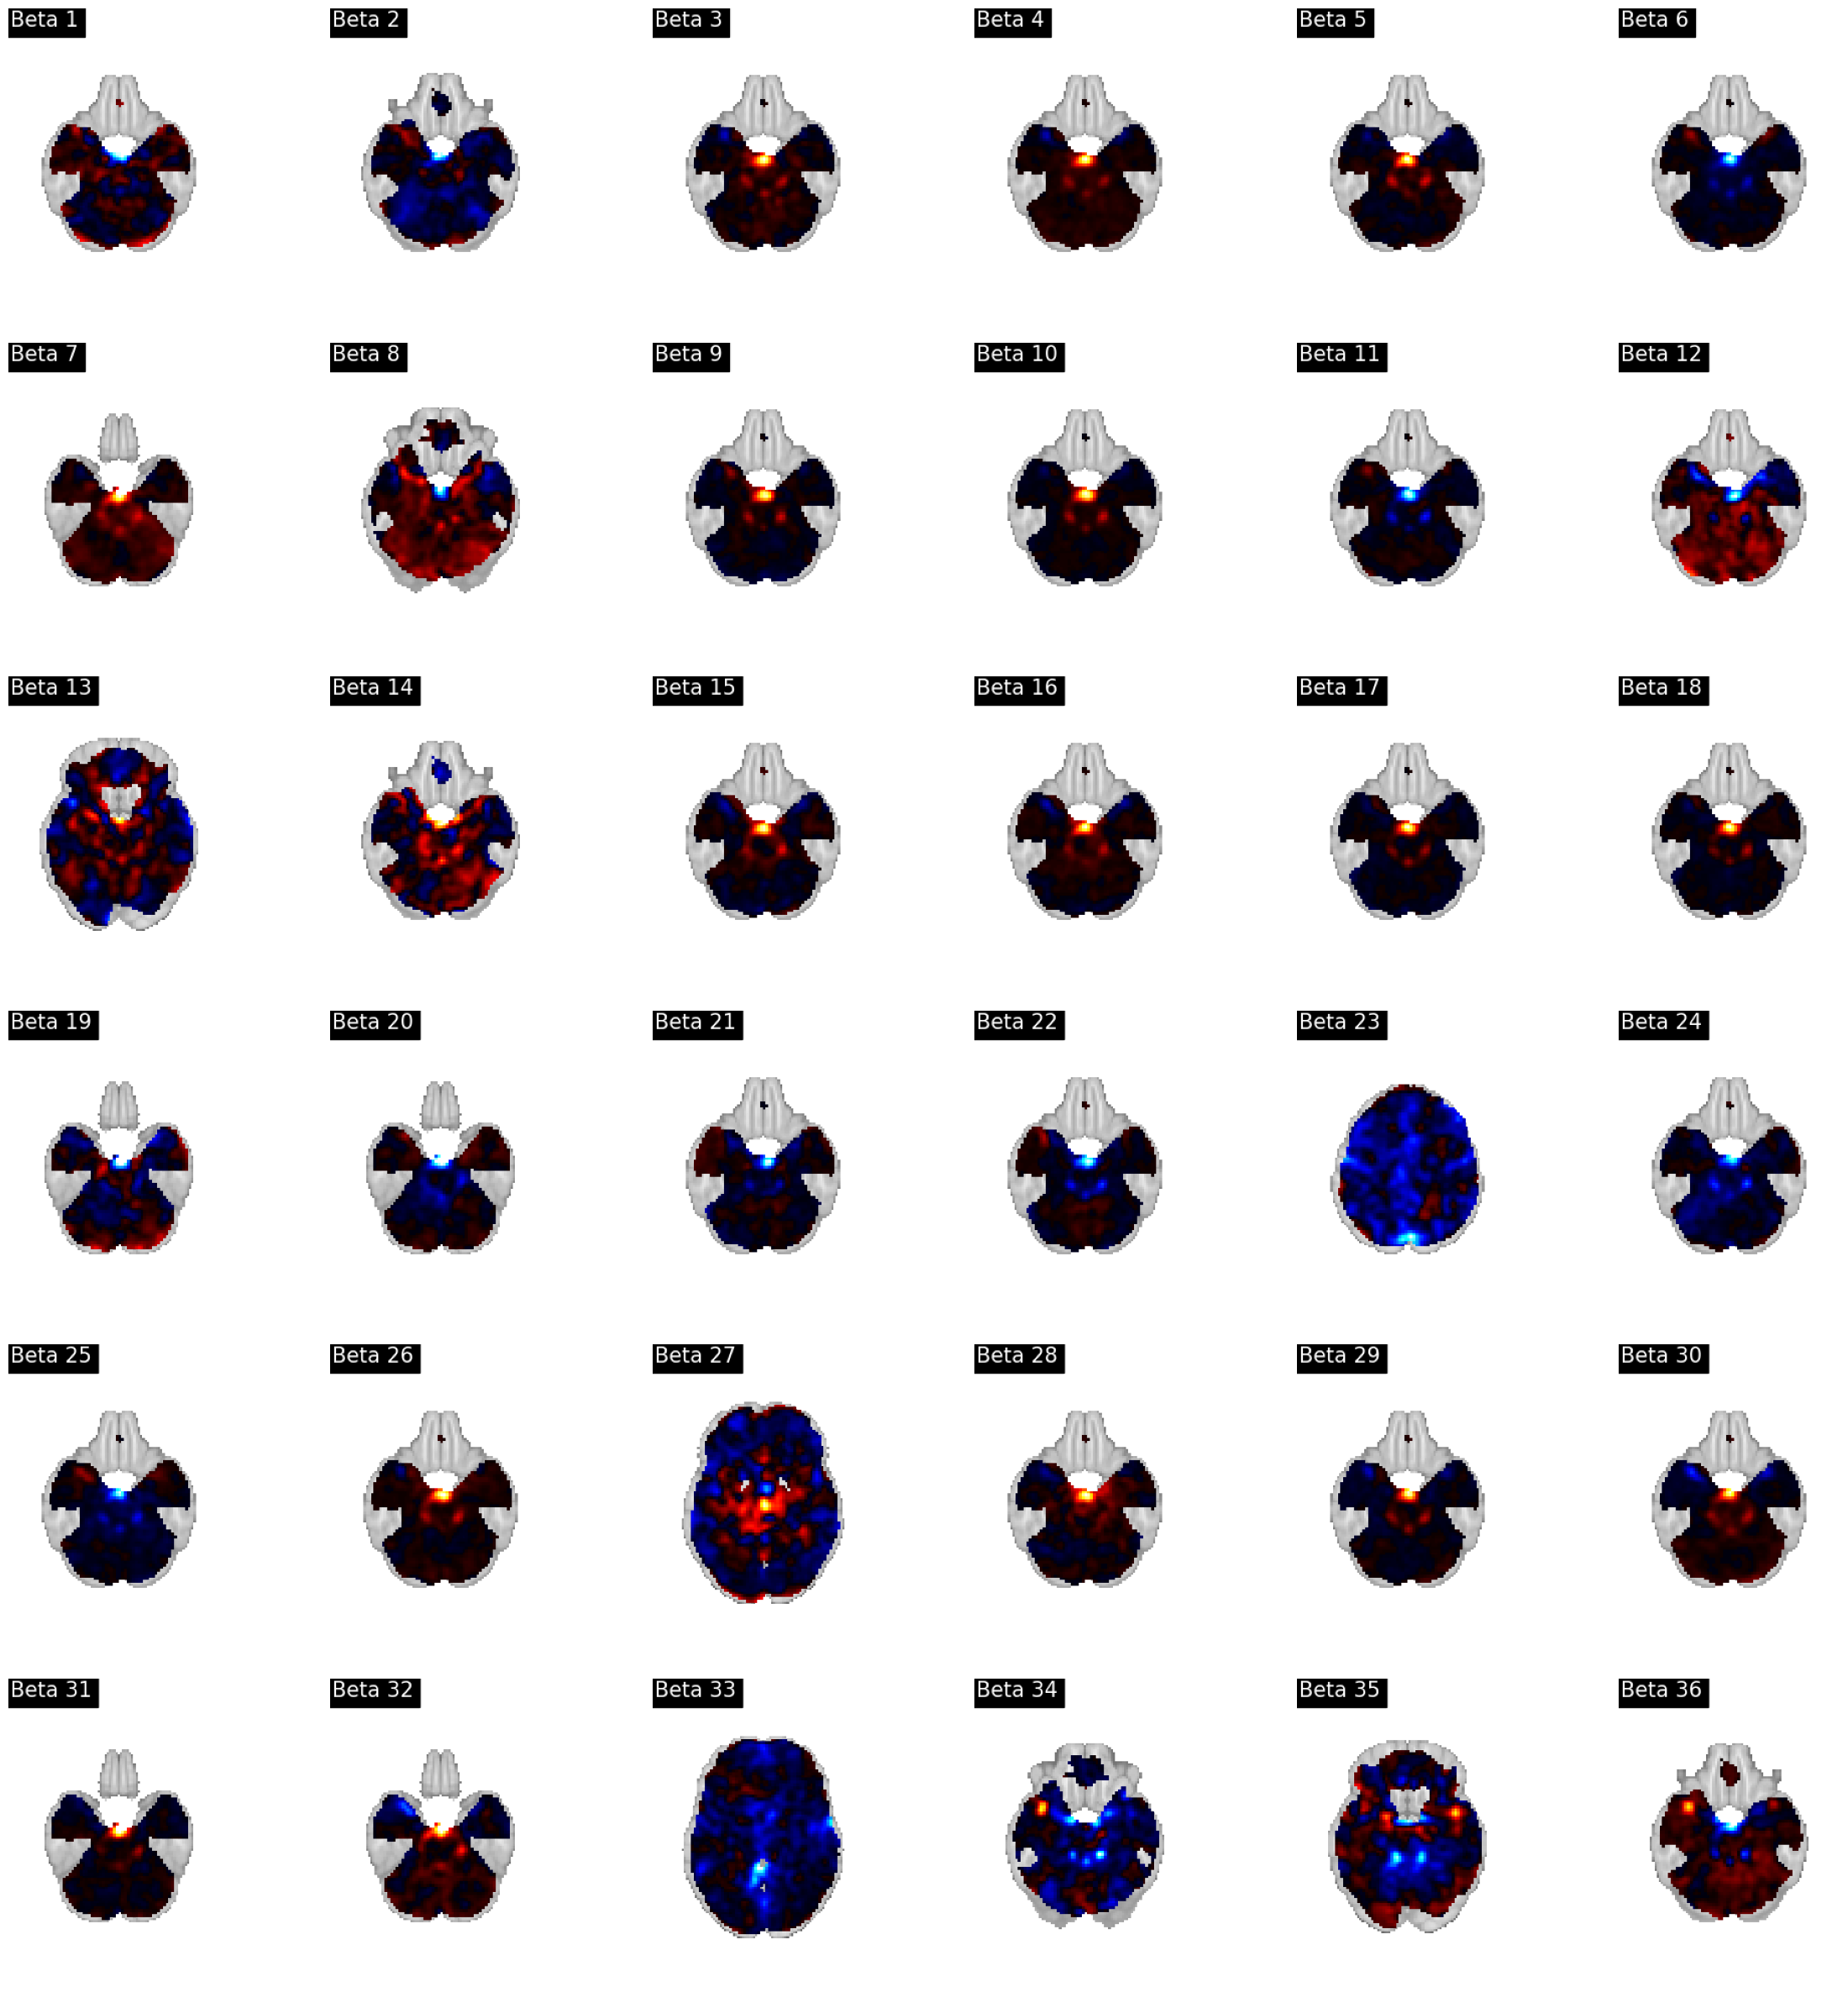

In [ ]:
n_plots = betas.shape[0]
n_cols = 6
n_rows = int(np.ceil(n_plots / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axs = axs.flatten()

for idx in range(n_plots):
    data2d = np.zeros([betas.shape[0], n_voxels_total])
    data2d[:, mask_bool_1D_idx] = betas
    data3D = data2d[idx, :].reshape(mask.shape)
    new_img = nib.Nifti1Image(data3D, mask.affine)

    # Plot and save to buffer
    display = plotting.plot_stat_map(
        new_img,
        display_mode='z',
        cut_coords=1,
        title=f"Beta {idx+1}",
        colorbar=False,
        annotate=False,
        draw_cross=False
    )

    buf = BytesIO()
    display.savefig(buf)
    buf.seek(0)
    img = Image.open(buf)
    axs[idx].imshow(img)
    axs[idx].axis('off')

    display.close()

# Hide unused subplots
for j in range(n_plots, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
plt.show()

## plot Betas as boolean masks


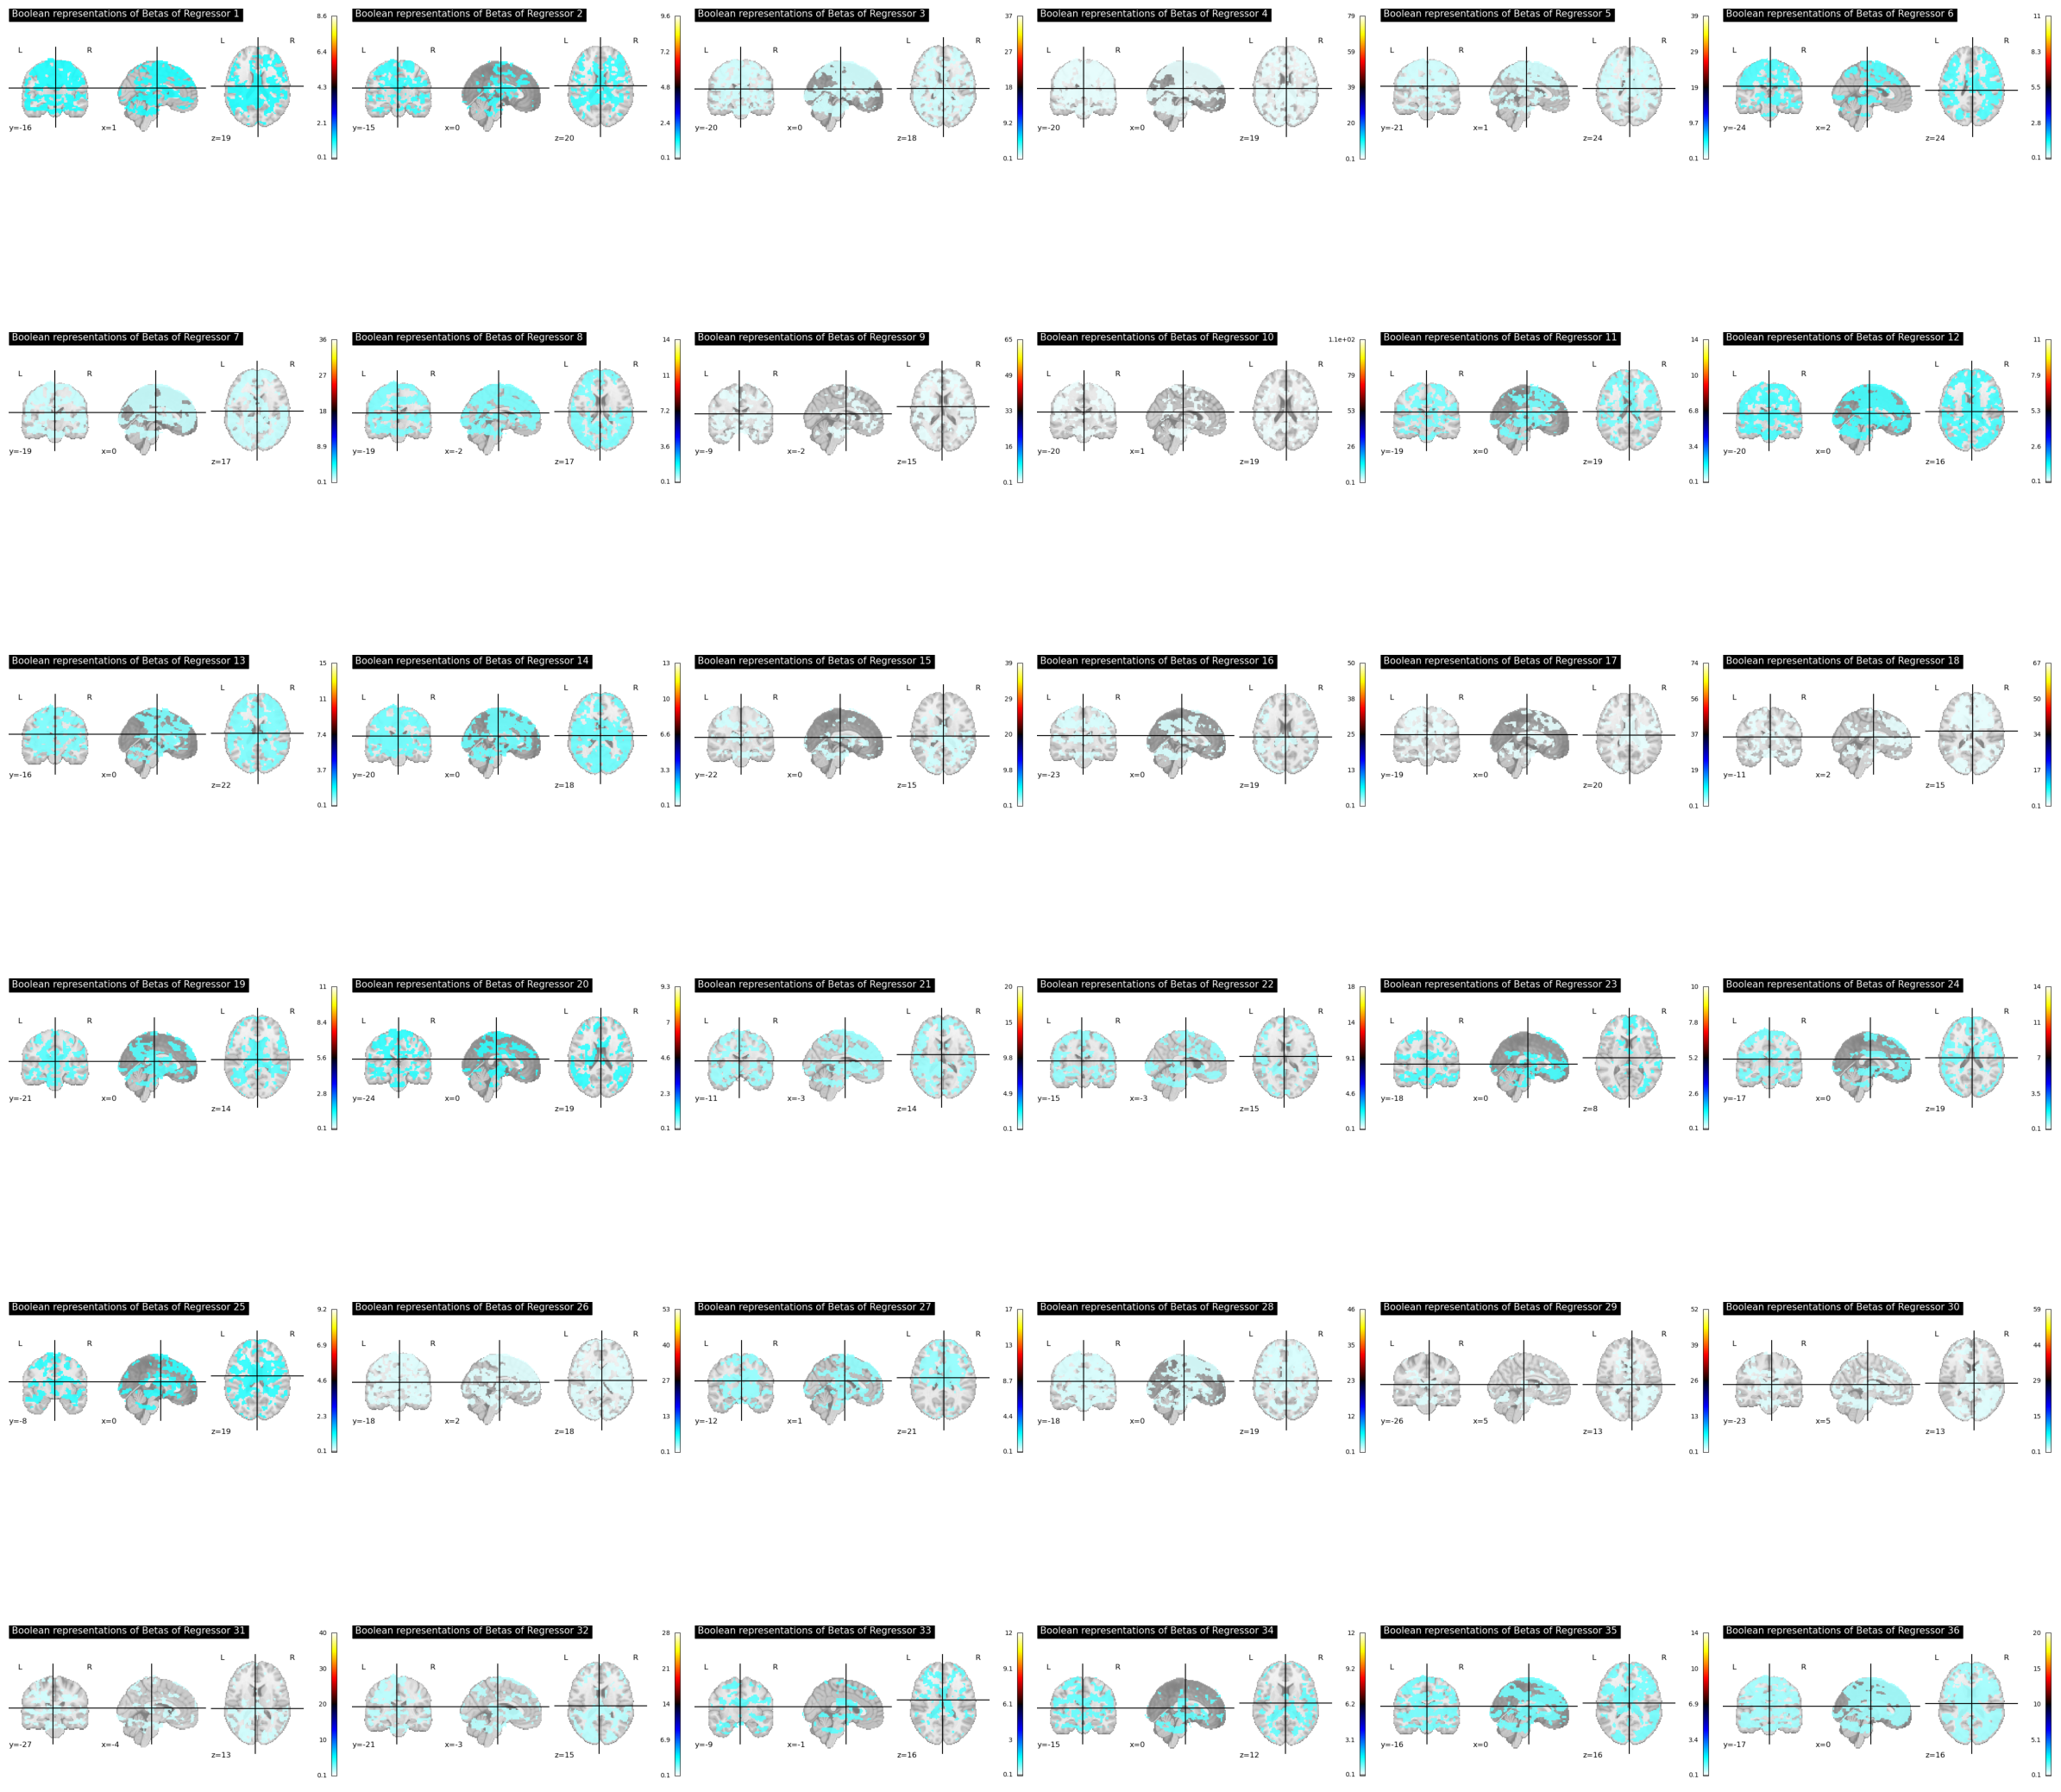

In [ ]:
n_plots = betas.shape[0]
n_cols = 6
n_rows = int(np.ceil(n_plots / n_cols))

fig, axs = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
axs = axs.flatten()

for idx in range(n_plots):
    data2d = np.zeros([betas.shape[0], n_voxels_total])
    data2d[:, mask_bool_1D_idx] = betas
    data3D = data2d[idx, :].reshape(mask.shape)
    new_img = nib.Nifti1Image(data3D, mask.affine)

    data3D_bool = np.zeros(data3D.shape)
    data3D_bool[data3D > 0] = 1
    bool_img = nib.Nifti1Image(data3D_bool, mask.affine)

    display = plotting.plot_stat_map(
        bool_img,
        title=f"Boolean representations of Betas of Regressor {idx + 1}",
        threshold=0.1,
        display_mode="ortho",
        colorbar=True,
        vmax=np.nanmax(data3D),
        alpha=0.9
    )

    buf = BytesIO()
    display.savefig(buf)
    buf.seek(0)
    img = Image.open(buf)
    axs[idx].imshow(img)
    axs[idx].axis('off')

    display.close()

# Hide unused subplots
for j in range(n_plots, len(axs)):
    axs[j].axis('off')

plt.tight_layout()
# plt.savefig("compiled_betas.png", dpi=300)
plt.show()

## create 2D Betas data

In [ ]:
mask_data = mask.get_fdata()
centers, neighbors = get_volume_searchlight(mask_data, radius=5, threshold=0.5)

data2d = np.zeros([betas.shape[0],n_voxels_total])
data2d[:,mask_bool_1D_idx] = betas

data2d = np.nan_to_num(data2d)


In [24]:
# Get RDMs
SL_rdms = get_searchlight_RDMs(data2d, centers, neighbors, info['condition'], method=cfg.RDMmethod)

Calculating RDMs...:   0%|          | 0/100 [00:00<?, ?it/s]

Calculating RDMs...: 100%|██████████| 100/100 [00:35<00:00,  2.79it/s]


In [25]:
joblib.dump(SL_rdms, outFiles['SL_rdms'])
joblib.dump(centers, outFiles['centers'])
joblib.dump(neighbors, outFiles['neighbors'])

# 6) compare Searchlight RDMs with model RDM
print('    - Evaluating RDMs...')

eval_results = evaluate_models_searchlight(SL_rdms, model, eval_fixed, method = cfg.RSAmethod)
eval_score = [float(e.evaluations) for e in eval_results]

joblib.dump(eval_results, outFiles['eval_results'])

x, y, z = mask.shape
RDM_brain = np.zeros([x*y*z])
RDM_brain[SL_rdms.rdm_descriptors['voxel_index']] = eval_score
RDM_brain = RDM_brain.reshape(mask.shape)

joblib.dump(RDM_brain, outFiles['RDM_brain'])


    - Evaluating RDMs...


Evaluating models for each searchlight: 100%|██████████| 92472/92472 [01:52<00:00, 819.15it/s]
/tmp/ipykernel_3606831/3424269925.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eval_score = [float(e.evaluations) for e in eval_results]


['/home/reabt/experiments/ncc/MRI/data/rsa/SetupConfig_E1/19910823ssld/SL_partial_0_M4B_6Cond_suprasensory_crossnobis_spearman_r2_thr0_5_RDM_brain.pkl']

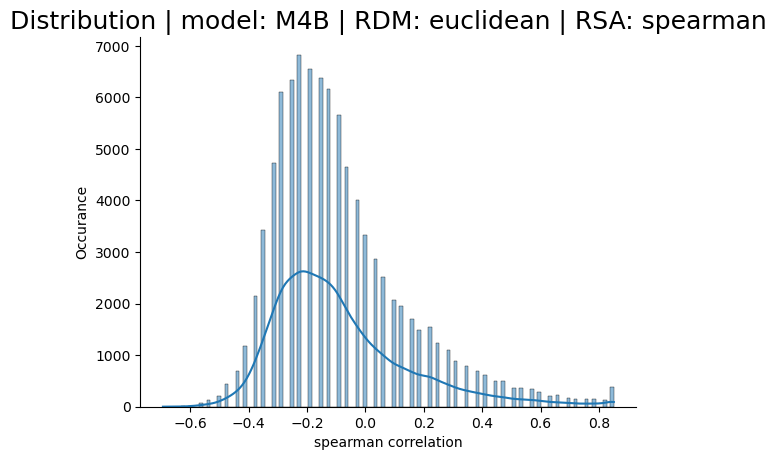

In [27]:

# Plot 1: histogram
sns.histplot(eval_score, kde=True)
plt.title(paths['plot1_title'], size=18)
plt.ylabel('Occurance')
plt.xlabel(f'{cfg.RSAmethod} correlation')
sns.despine()
# plt.savefig(paths['DistPlotFile'], dpi=300)
# plt.close()


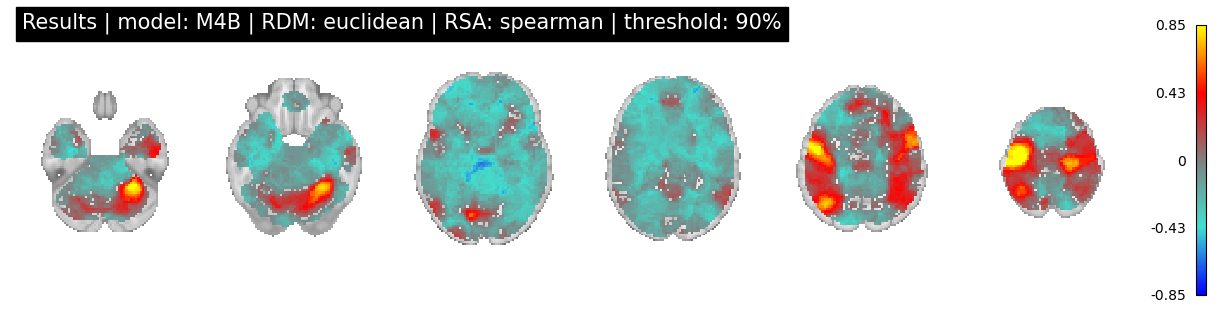

In [29]:

# Plot 2: brain map
def RDMcolormapObject(direction=1):
    cs = ['blue', 'turquoise', 'gray', 'red', 'yellow'] if direction else ['yellow', 'red', 'gray', 'turquoise', 'blue']
    return matplotlib.colors.LinearSegmentedColormap.from_list("", cs)

threshold = np.percentile(eval_score, cfg.resultsPlot_thr)
plot_img = new_img_like(mask, RDM_brain)
cmap = RDMcolormapObject()

fig = plt.figure(figsize=(12, 3))
plotting.plot_stat_map(
    plot_img, colorbar=True, 
    # threshold=threshold,
    cut_coords=[-30, -20, 0, 20, 40, 60],
    display_mode='z', draw_cross=False, figure=fig,
    title=f'{paths['plot2_title']} | threshold: {cfg.resultsPlot_thr}%', cmap=cmap,
    black_bg=False, annotate=False
)
# plt.savefig(paths['ResultsPlotFile'], dpi=300)
# plt.close()